<a href="https://colab.research.google.com/github/Victorbenavides/Prediccion_Agronomia/blob/main/Prediccion_Agronomia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Error cuadrático medio: 3.1972269075689947
R^2: 0.29108050829955756


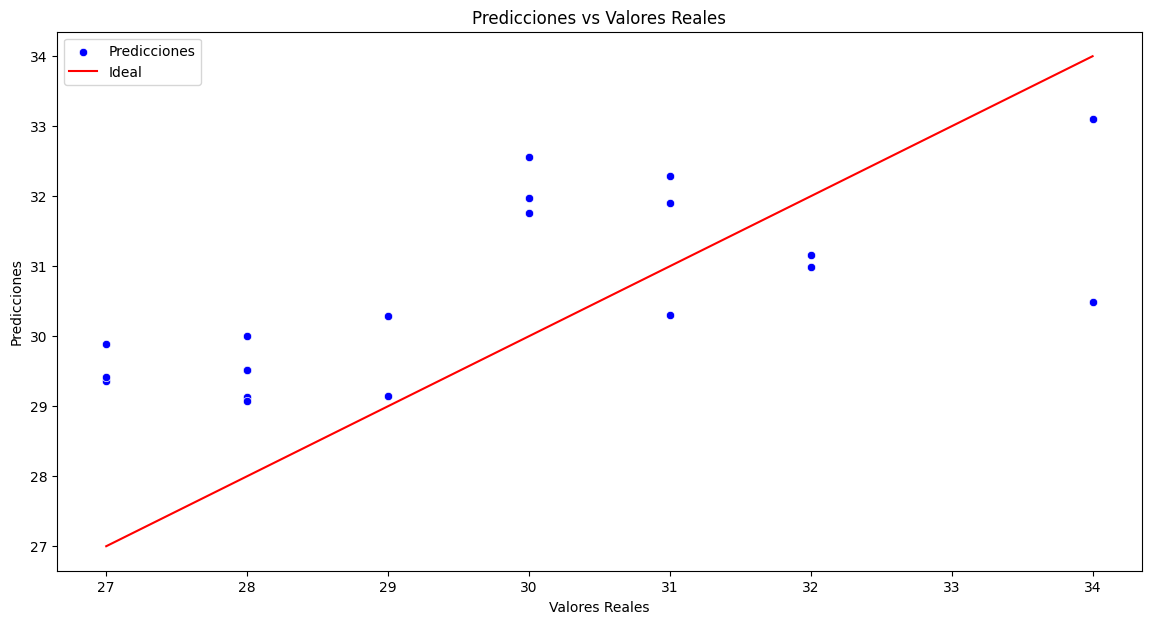

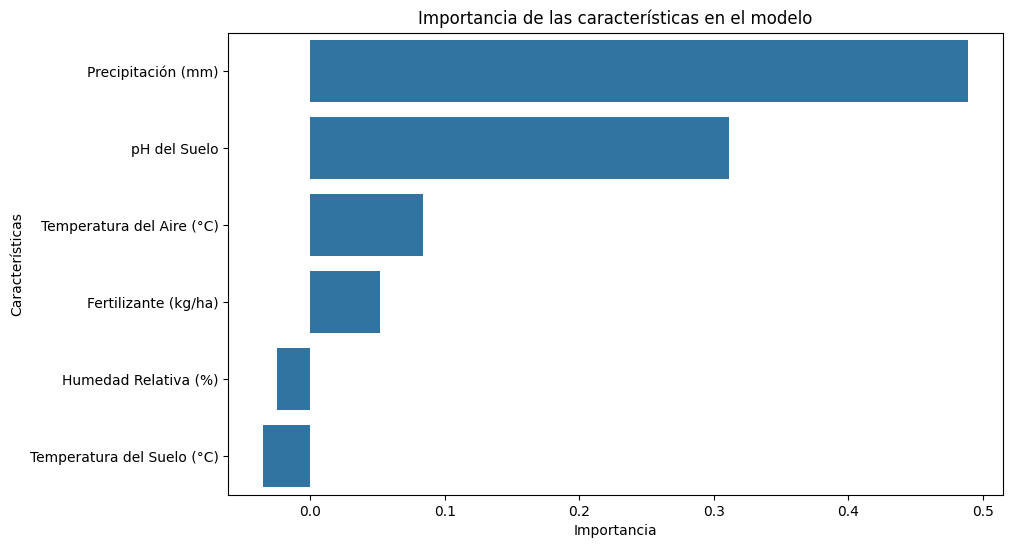

In [ ]:
# Se importan las librerias necesarias
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Leer los datos desde el archivo Excel
datos = pd.read_excel('datos_climaticos_completo.xlsx')

# Seleccionar características (X) y la variable objetivo (y)
X = datos[['Temperatura del Suelo (°C)', 'Precipitación (mm)', 'Temperatura del Aire (°C)', 'Humedad Relativa (%)', 'pH del Suelo', 'Fertilizante (kg/ha)']]
y = datos['Humedad del Suelo (%)']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo
modelo = LinearRegression()

# Entrenar el modelo
modelo.fit(X_train, y_train)

# Hacer predicciones sobre el conjunto de prueba
predicciones = modelo.predict(X_test)

# Calcular el MSE y R^2
mse = mean_squared_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print(f'Error cuadrático medio: {mse}')
print(f'R^2: {r2}')

# Visualizar las predicciones
plt.figure(figsize=(14, 7))
sns.scatterplot(x=y_test, y=predicciones, color='blue', label='Predicciones')
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color='red', label='Ideal')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.legend()
plt.show()

# Visualizar la importancia de las características
importancia_caracteristicas = pd.Series(modelo.coef_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importancia_caracteristicas, y=importancia_caracteristicas.index)
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.title('Importancia de las características en el modelo')
plt.show()
